# ML Week 16: Classification II - Transfer Learning

We have now seen a powerful CNN (ResNet) which can learn to distinguish 1000 classes!

This is a nice bit number, but there are unfortunately more than 1000 types of objects in existence in the world :(

What do we do if we want to train a classifier to identify a new class, beyond the dataset it is already trained on?

In theory this could be done from scratch, but practically nobody every does this - it is simply too computationally intensive.

Instead, people depend on what is called "Transfer Learning". This uses a network in which the weights have already been trained on a large dataset (ie ImageNet1000). Then the newtwork is trained more on new classes.

Let's see how this works!

Source: https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

License: BSD

Author: Sasank Chilamkurthy

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True

### Load Data

We will use torchvision and torch.utils.data packages for loading the data.

The problem we’re going to solve today is to train a model to classify the pokémon Pikachu and Pichu. We have about 50 training images each for each. There are 20 validation images for each class. Usually, this is a very small dataset to generalize upon, if trained from scratch. Since we are using transfer learning, we should be able to generalize so-so. If we were really planning on making this something useful, 100 training and 50 validation would be better.

**Note:** The most thorough way to do this would be to have a large corpus of images (let's say 200) and perform k-fold cross validation for multiple runs (ie. 3-fold with 100 train and 50 test, randomly chosen each time). Then the remaining 50 would be held for a final validation, simply by testing the model. This is a way of meta-testing the performance, and controlling for meta-parametres such as the number of k-fold splits, the generalizability of the model, etc.

In [27]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(256),  # Note - this could be closer (ie 224), and could be done a bit more cleanly
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Mean and standard deviation of ImageNet1000 Dataset
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),  # Note - transforms.Resize((256,256)) squishes to avoid cropping out the object
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Mean and standard deviation of ImageNet1000 Dataset
    ]),
}

data_dir = './data/pokemon_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### Visualize a few images

Let’s visualize a few training images so as to understand the data augmentations.

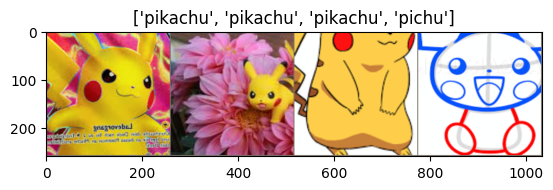

In [28]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

### Defining Model Training

Now, let’s write a general function to train a model. This could be applied to any model, and indeed code blocks like this are found across lots of ML applications.

In [29]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')
        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)  # torch.max returns both max values and indices. We only need the indices (as they correspond to the class)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

### Setting Model Parametres

Let's now set:
* The model weights
* The number of classes (output neurons)
* The loss function
* The optimizer
* The learning rate (lr)

In [ ]:
model = models.resnet18(weights='IMAGENET1K_V1')

# This checks how many features there are on the last layer (in our cases 1000 - corresponding to the 1000 ImageNet classes)
num_ftrs = model.fc.in_features

# Here we add another FC layer going from 1000 layers to 2 classes (we only have 2 classes: pikachu and pichu)
model.fc = nn.Linear(num_ftrs, 2)

model_ft = model.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

### Finally we can train!

In [ ]:
model_ft = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.7919 Acc: 0.5579
val Loss: 0.7378 Acc: 0.5789

Epoch 1/24
----------
train Loss: 0.6840 Acc: 0.6316
val Loss: 1.2948 Acc: 0.5789

Epoch 2/24
----------
train Loss: 0.7041 Acc: 0.6316
val Loss: 0.4540 Acc: 0.7632

Epoch 3/24
----------
train Loss: 0.4225 Acc: 0.8421
val Loss: 0.4058 Acc: 0.8421

Epoch 4/24
----------
train Loss: 0.3658 Acc: 0.8526
val Loss: 0.6645 Acc: 0.7632

Epoch 5/24
----------
train Loss: 0.3511 Acc: 0.8421
val Loss: 0.8587 Acc: 0.7895

Epoch 6/24
----------
train Loss: 0.5463 Acc: 0.7895
val Loss: 0.3887 Acc: 0.8684

Epoch 7/24
----------
train Loss: 0.3387 Acc: 0.9158
val Loss: 0.3093 Acc: 0.8947

Epoch 8/24
----------
train Loss: 0.2430 Acc: 0.9053
val Loss: 0.2691 Acc: 0.8421

Epoch 9/24
----------
train Loss: 0.3722 Acc: 0.8632
val Loss: 0.2779 Acc: 0.8421

Epoch 10/24
----------
train Loss: 0.2289 Acc: 0.9053
val Loss: 0.3020 Acc: 0.8684

Epoch 11/24
----------
train Loss: 0.1534 Acc: 0.9158
val Loss: 0.3812 Acc: 0.8684

Ep

### Checking Model Performance

In [33]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        
        model.train(mode=was_training)

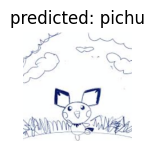

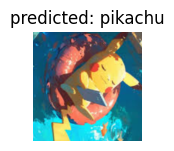

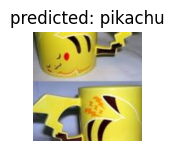

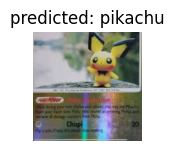

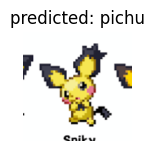

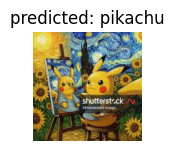

In [38]:
visualize_model(model_ft)

### What About a New Image?

In [40]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

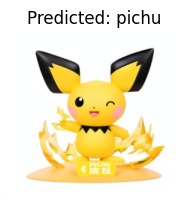

In [41]:
visualize_model_predictions(model_ft, img_path='img.jpg')

# Exercises

### Exercise 1

The weights are stored in "model_ft.parameters()".

(Note: weights are sometimes called "parametres" -- this is why we say "hyperparametres" to distinguish higher-level parametres from the simple weight parametres).

You can loop over them with "for param in model_ft.named_parameters():"

This will return both a "name" and a tensor for each iteration of the loop.

For each loop print the name of the parameter and the shape of the tensor (printing the whole tensor is impractical - they are pretty large!).

In [64]:
for name, param in model_ft.named_parameters():
    print(name)
    print(param.shape)

conv1.weight
torch.Size([64, 3, 7, 7])
bn1.weight
torch.Size([64])
bn1.bias
torch.Size([64])
layer1.0.conv1.weight
torch.Size([64, 64, 3, 3])
layer1.0.bn1.weight
torch.Size([64])
layer1.0.bn1.bias
torch.Size([64])
layer1.0.conv2.weight
torch.Size([64, 64, 3, 3])
layer1.0.bn2.weight
torch.Size([64])
layer1.0.bn2.bias
torch.Size([64])
layer1.1.conv1.weight
torch.Size([64, 64, 3, 3])
layer1.1.bn1.weight
torch.Size([64])
layer1.1.bn1.bias
torch.Size([64])
layer1.1.conv2.weight
torch.Size([64, 64, 3, 3])
layer1.1.bn2.weight
torch.Size([64])
layer1.1.bn2.bias
torch.Size([64])
layer2.0.conv1.weight
torch.Size([128, 64, 3, 3])
layer2.0.bn1.weight
torch.Size([128])
layer2.0.bn1.bias
torch.Size([128])
layer2.0.conv2.weight
torch.Size([128, 128, 3, 3])
layer2.0.bn2.weight
torch.Size([128])
layer2.0.bn2.bias
torch.Size([128])
layer2.0.downsample.0.weight
torch.Size([128, 64, 1, 1])
layer2.0.downsample.1.weight
torch.Size([128])
layer2.0.downsample.1.bias
torch.Size([128])
layer2.1.conv1.weight
tor

Look over the ResNet architecture. Does some of it look familiar?

FYI: "bn" refers to "Batch Normalization" and is a step in which a layer is normalized based on some statistical properties before continuing deeper into the network.

### Exercise 2

There is a second way to apply transfer learning that is quite a bit less computationally expensive and tends to also perform quite well.

A trained ResNet naturally becomes very powerful at analyzing photos and creating very distinctive feature vectors (this is sometimes known as a "feature extractor").

So it's not really necessary to retrain the entire network for new classes.

Instead we can simply retrain the last layer (the ones that goes from 1000 neurons to 2 neurons).

Implementing this in code is super easy. Nothing needs to be changed in the "train_model" function. You only need to make some very minor changes in the "Setting Model Parametres" code from above. Here's what to do:

1) In "model.parameters()" each layer has a property called "requires_grad". This refers to "Gradient Descent", which is how networks are trained. If you loop like you did in the last exercise and then check "param.requires_grad" you will see they should all be set to "True"
2) Now in your loop set every one to be "False".
3) The next steps should all be the same as before. When you add your new layer (model.fc = ...) the default is that requires_grad = True, so this final layer WILL still train.
4) The only other thing to do is that the optimizer has to be very slightly changed. It should only apply to the fully connected layers. Notice in the optim.SGD function the first parameter is "model.parameters()" change this to be "model.fc.parameters()".
5) That's it! Now you can run everything the same.

How is the performance compared to the full retraining?

In [ ]:
model2 = models.resnet18(weights='IMAGENET1K_V1')

for param in model2.parameters():
    param.requires_grad = False

num_ftrs = model2.fc.in_features  # When we add a new layer the default is that it has "requires_grad = True"
model2.fc = nn.Linear(num_ftrs, 2)

model2 = model2.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as opposed to before (this time we put "model2.fc")
optimizer = optim.SGD(model2.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [ ]:
model_ft = train_model(model2, criterion, optimizer, exp_lr_scheduler, num_epochs=25)

### Exercise 3

If you've gotten here, well done!

As a final exercise, why not try to create a classifier using your own classes? It can also be more than 2 if you'd like.

# Bonus Note for the Hardcore

### What if we want to learn a lot of new classes?

Transfer learning is still always better than training from scratch, but to learn a large number of new classes needs very heavy computation power.

Here is a 2019 case study where transfer learning was applied to ResNet150 to learn to distinguish between 196 different models of cars, reaching above 90% accuracy:

https://www.databricks.com/blog/2020/05/14/a-convolutional-neural-network-implementation-for-car-classification.html

Woker: 8 x NVIDIA Tesla K80 (with 12 GB of GPU memory)

Driver: NVIDIA V100 GPUs (16 GB VRAM each), 64 vCPUs, and 488 GB of system memory

*Note:* these GPU formats are now outdated.